# 04 — Figures (cross-tag geolocation replication)

`figures/main_result.png`: the headline cross-tag comparison.

- **Left** — for the four tags with an Argos referee, per-tag median
  great-circle error of **pangeo-fish vs Argos** (this replication) against
  **GPE3 vs Argos** (the paper's method). These four tags are the headline:
  they have positional ground truth.
- **Right** — for the three PAT-only tags (no referee), the **pangeo-fish vs
  GPE3** track agreement, shown separately and clearly flagged as *not* an
  accuracy validation (GPE3 is itself an estimate).

Per-tag track maps are written to `figures/tracks/` when cheap.

In [1]:
import json
from pathlib import Path

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.style.use("seaborn-v0_8-whitegrid")

In [2]:
RESULTS_DIR = Path("../results")
CLEAN_DIR = Path("../data/clean")
FIGURES_DIR = Path("../figures")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
(FIGURES_DIR / "tracks").mkdir(parents=True, exist_ok=True)

summary = pd.read_csv(RESULTS_DIR / "summary.csv")
aggregate = json.loads((RESULTS_DIR / "aggregate.json").read_text())

PF_C = "#C44E52"     # pangeo-fish (replication)
GPE3_C = "#4C72B0"   # GPE3 (paper baseline)
ARGOS_C = "#55A868"  # Argos referee

ok = summary[summary["status"] == "ok"].copy()
referee = ok[ok["has_referee"]].sort_values("tag")
patonly = ok[~ok["has_referee"]].sort_values("tag")

## Main figure — referee comparison (left) + PAT-only agreement (right)

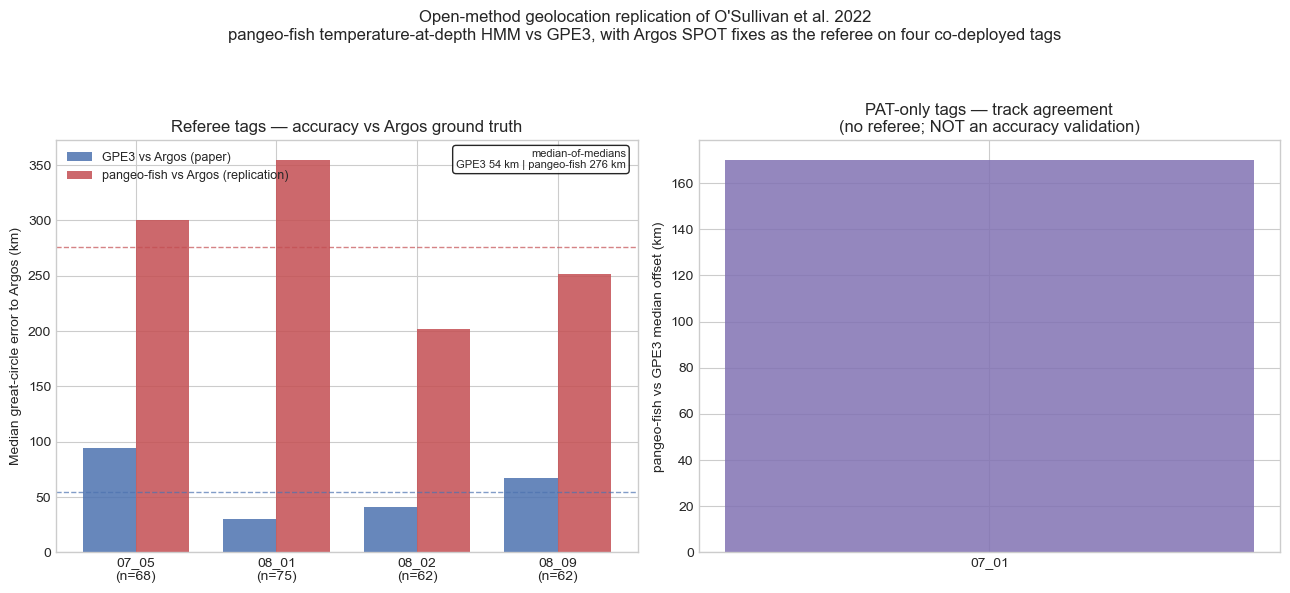

In [3]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 6))

# --- Left: pangeo-fish vs GPE3, both against the Argos referee ---
x = np.arange(len(referee))
w = 0.38
ax1.bar(x - w / 2, referee["gpe3_vs_argos_median_km"], width=w,
        color=GPE3_C, alpha=0.85, label="GPE3 vs Argos (paper)")
ax1.bar(x + w / 2, referee["pf_vs_argos_median_km"], width=w,
        color=PF_C, alpha=0.85, label="pangeo-fish vs Argos (replication)")
ax1.set_xticks(x)
ax1.set_xticklabels([f"{t}\n(n={int(n)})"
                     for t, n in zip(referee["tag"],
                                     referee["n_argos_fixes"].fillna(0))])
ax1.set_ylabel("Median great-circle error to Argos (km)")
ax1.set_title("Referee tags — accuracy vs Argos ground truth")
ax1.legend(loc="upper left", fontsize=9, framealpha=0.9)

pf_agg = aggregate.get("pf_vs_argos_median_of_medians_km")
gpe3_agg = aggregate.get("gpe3_vs_argos_median_of_medians_km")
if pf_agg is not None and gpe3_agg is not None:
    ax1.axhline(gpe3_agg, color=GPE3_C, ls="--", lw=1, alpha=0.7)
    ax1.axhline(pf_agg, color=PF_C, ls="--", lw=1, alpha=0.7)
    ax1.annotate(
        f"median-of-medians\nGPE3 {gpe3_agg:.0f} km | "
        f"pangeo-fish {pf_agg:.0f} km",
        xy=(0.98, 0.98), xycoords="axes fraction", ha="right", va="top",
        fontsize=8, bbox=dict(boxstyle="round", fc="white", alpha=0.85))

# --- Right: PAT-only tags, pangeo-fish vs GPE3 (NOT a validation) ---
if len(patonly):
    xp = np.arange(len(patonly))
    ax2.bar(xp, patonly["pf_vs_gpe3_median_km"], width=0.5,
            color="#8172B3", alpha=0.85)
    ax2.set_xticks(xp)
    ax2.set_xticklabels(list(patonly["tag"]))
else:
    ax2.text(0.5, 0.5, "no PAT-only tags completed", ha="center", va="center",
             transform=ax2.transAxes)
ax2.set_ylabel("pangeo-fish vs GPE3 median offset (km)")
ax2.set_title("PAT-only tags — track agreement\n(no referee; NOT an accuracy "
              "validation)")

fig.suptitle(
    "Open-method geolocation replication of O'Sullivan et al. 2022\n"
    "pangeo-fish temperature-at-depth HMM vs GPE3, with Argos SPOT fixes as the "
    "referee on four co-deployed tags",
    fontsize=12)
fig.tight_layout(rect=(0, 0, 1, 0.93))
fig.savefig(FIGURES_DIR / "main_result.png", dpi=150, bbox_inches="tight")
plt.show()

## Per-tag track maps (cheap; one panel per completed tag)

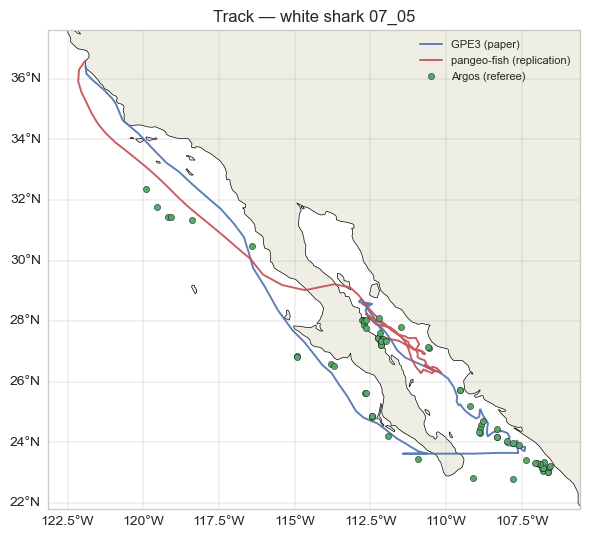

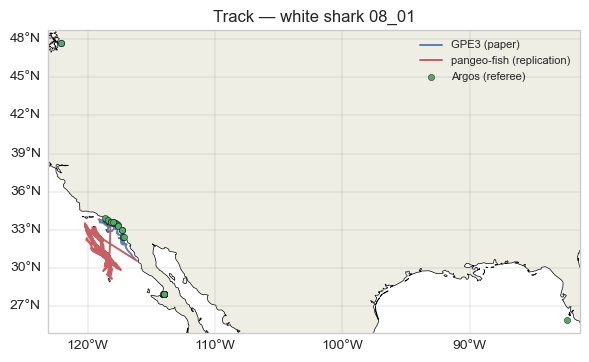

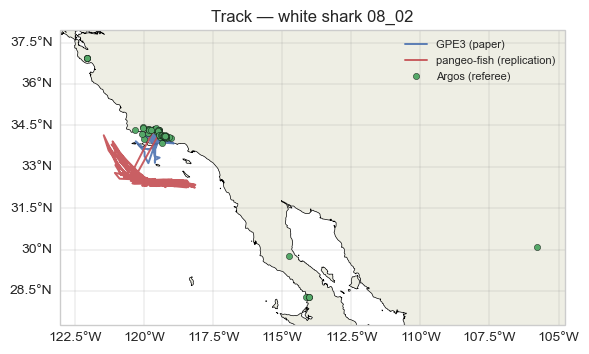

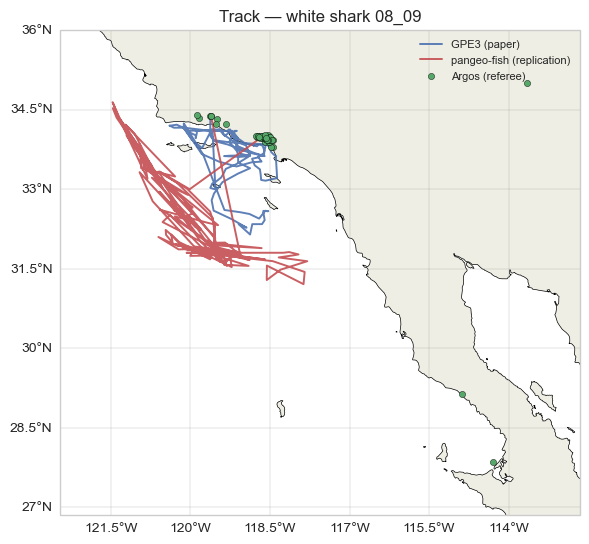

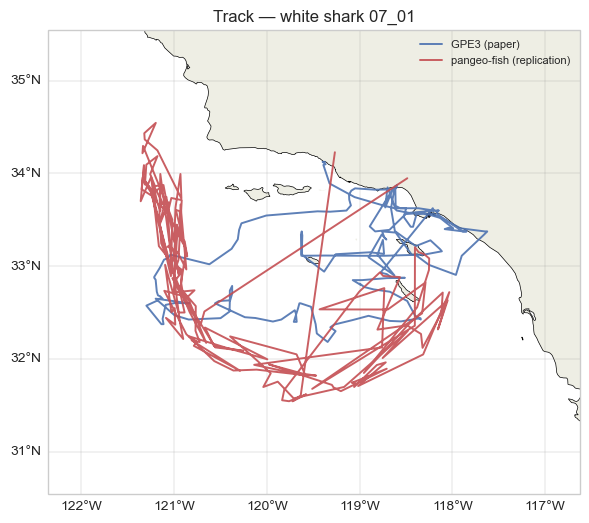

In [4]:
def track_map(shark: str) -> None:
    pf_path = RESULTS_DIR / f"pangeo_fish_track_{shark}.csv"
    gpe3_path = CLEAN_DIR / f"gpe3_{shark}.csv"
    if not pf_path.exists() or not gpe3_path.exists():
        return
    pf = pd.read_csv(pf_path, parse_dates=["time"])
    gpe3 = pd.read_csv(gpe3_path, parse_dates=["time"])
    argos_path = CLEAN_DIR / f"argos_{shark}.csv"
    argos = (pd.read_csv(argos_path, parse_dates=["time"])
             if argos_path.exists() else None)

    lons = list(pf["longitude"]) + list(gpe3["longitude"])
    lats = list(pf["latitude"]) + list(gpe3["latitude"])
    if argos is not None:
        lons += list(argos["longitude"])
        lats += list(argos["latitude"])

    fig = plt.figure(figsize=(6, 6))
    ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())
    ax.set_extent([min(lons) - 1, max(lons) + 1, min(lats) - 1, max(lats) + 1],
                  crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.LAND, facecolor="#eeeee4", zorder=0)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
    gl = ax.gridlines(draw_labels=True, linewidth=0.3, color="gray", alpha=0.5)
    gl.top_labels = gl.right_labels = False
    ax.plot(gpe3["longitude"], gpe3["latitude"], "-", color=GPE3_C, lw=1.4,
            alpha=0.9, label="GPE3 (paper)", transform=ccrs.PlateCarree())
    ax.plot(pf["longitude"], pf["latitude"], "-", color=PF_C, lw=1.4, alpha=0.9,
            label="pangeo-fish (replication)", transform=ccrs.PlateCarree())
    if argos is not None:
        ax.scatter(argos["longitude"], argos["latitude"], s=20, color=ARGOS_C,
                   edgecolor="k", linewidth=0.3, zorder=5,
                   label="Argos (referee)", transform=ccrs.PlateCarree())
    ax.set_title(f"Track — white shark {shark}")
    ax.legend(loc="upper right", fontsize=8, framealpha=0.9)
    fig.tight_layout()
    fig.savefig(FIGURES_DIR / "tracks" / f"track_{shark}.png", dpi=150,
                bbox_inches="tight")
    plt.show()


for shark in ok["tag"]:
    track_map(shark)

## Console summary

In [5]:
print("Per-tag results:")
print(summary.to_string(index=False))
print("\nAggregate (referee tags):")
print(json.dumps(aggregate, indent=2))

Per-tag results:
  tag  deploy_days  has_referee  n_argos_fixes  healpix_level  fitted_sigma_rad  pf_vs_argos_median_km  gpe3_vs_argos_median_km  pf_vs_gpe3_median_km        status                                                                                                                                                                                                                                   error
07_05        132.0         True           68.0              9          0.007012             300.317173                94.514483            258.212594            ok                                                                                                                                                                                                                                     NaN
08_01        148.0         True           75.0              9          0.093745             354.456820                30.383217            273.108176            ok                            